# Natural Language Processing Coursework 2: Categorise job postings as either real or fake.
**Problem**: Train and predict to test whether a job posting is real or fake.
  * This dataset can be found at: https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction?resource=download
  * Dataset Properties:
    * Dataset: 17,880 records  
    * Main Features: title, company_profile, description, requirements, benefits
    * Target Variable: fraudulent

# Importing Libraries + Setup

In [ ]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Text Processing Libraries
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# SKLearn Libraries
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# Test that the libraries have loaded
print("All libraries loaded")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


All libraries loaded


# Load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fake_job_postings.csv')
print("Dataset loaded")
print("Dataset Info:")
print(f"Dataset shape {df.shape}")
print(f"Dataset Columns {df.columns.tolist()}")
print(f"Dataset head \n{df.head(5)}")
print()
#print(f"Fraudulent Postings (1 = fake, 0 = real):\n{df['fraudulent'].value_counts()}")
print()
#print(f"Missing value count per column:\n{df.isnull().sum().sort_values()}")

Dataset loaded
Dataset Info:
Dataset shape (17880, 18)
Dataset Columns ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']
Dataset head 
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success      

# Combining + Cleaning Text
* The text must be cleaned and empty / NaN strings must be dealt with



In [ ]:
# Combine relevant text columns for ease of use
# don't care for other ones as they are irrelevant, mostly, to seeing i the job is real or fake
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# Fill all NaN values in these text columns with empty strings
df[text_columns] = df[text_columns].fillna('')

# Combine all the relevant text columns into one field for the model to train on
df['combined_columns'] = df[text_columns].apply(lambda row: ' '.join(row), axis=1)

# Print the first 400 values from that field
print("Text before cleanup:")
print(df['combined_columns'][0][:400])

# Clean up the combined text so that it is plain lowercase text only - make it a new field
df['cleaned_text'] = df['combined_columns'].str.lower() # make it all lowercase
df['cleaned_text'] = df['cleaned_text'].str.replace(r'<[^>]+>', ' ', regex=True) # remove the html tags
df['cleaned_text'] = df['cleaned_text'].str.replace(r'http\S+|www\S+', '', regex=True) # remove any urls
df['cleaned_text'] = df['cleaned_text'].str.replace(r'[^a-z\s]', '', regex=True) # remove any numbers - this adds a few issues but is mostly useful, issues that only relate to brandnames and other things like that
df['cleaned_text'] = df['cleaned_text'].str.replace(r'\s+', ' ', regex=True).str.strip() # remove any extra spaces

# Example of after cleanup
print("Text after cleanup:")
print(df['cleaned_text'][0][:400])

Text before cleanup:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly
Text after cleanup:
marketing intern were food and weve created a groundbreaking and awardwinning cooking site we support connect and celebrate home cooks and give them everything they need in one placewe have a top editorial business and engineering team were focused on using technology to find new and better ways to connect people around their specific food interests and to offer them superb highly curated informat


# Removing Stopwords
* The stopwords should be removed as they appear a lot in the text without adding any more information or context for the model to train on.

In [ ]:
# Get all stopwords
# use set as its faster for lookup compared to creating an array
stopword_list = set(stopwords.words('english'))

# define a function as a loop so the spaces can stay after each word
def remove_stopwords(text):
  tokens_list = word_tokenize(text)
  filtered_text = [word for word in tokens_list if word not in stopword_list and len(word) > 1]
  return ' '.join(filtered_text)

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)
print(df['cleaned_text'][0][:300])

marketing intern food weve created groundbreaking awardwinning cooking site support connect celebrate home cooks give everything need one placewe top editorial business engineering team focused using technology find new better ways connect people around specific food interests offer superb highly cu


# Padding the sentences
* We must pad the sentences as NLP models have to have each word numbered to learn from as they cannot use raw text data.

In [ ]:
# Keep the 20,000 most frequent words
MAX_VOCABULARY = 20000
# add 300 tokens to the end of each posting that is processed
MAX_LENGTH = 300

tokenizer = Tokenizer(num_words=MAX_VOCABULARY, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])

print(f"Unique words seen: {len(tokenizer.word_index)}")
print(f"Most Common Words: {list(tokenizer.word_index.items())[1:6]}")

# Convert the text into sequences of numbers form the unique words
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# we pad all the sequences to the length of MAX_LENGTH
# post padding means adding 0's until the length is reached
# post truncating means cutting longer squences short

# X = all the text data
# y = fraudulent or not
X = pad_sequences(sequences, maxlen = MAX_LENGTH, padding = 'post', truncating = 'post')
y = df['fraudulent'].values

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

# Example of padded sequence
print(f"First 20 tokens of data 0: {X[0][:20]}")
print(f"Label for posting 0: {y[0]}")

Unique words seen: 155793
Most Common Words: [('work', 2), ('experience', 3), ('team', 4), ('business', 5), ('company', 6)]
X Shape: (17880, 300)
y Shape: (17880,)
First 20 tokens of data 0: [  20 1207  392  554  792 3211 1809 2586  299   32 1198 4014  142 3420
  533  683   97   48 7149  210]
Label for posting 0: 0


# Implementing GloVe embeddings
* GloVe is a pre-trained embedding meaning that it already understands word meanings, so we use it to save on training.

In [ ]:
# Get GloVe path from google drive as a const
GLOVE_PATH = '/content/drive/MyDrive/wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt'

embeddings_index = {}
embeddings_skipped = 0

# Create a list of all vectors associated with a word, and store that in a dictionary
with open(GLOVE_PATH, encoding='utf-8') as f:
  for line in f:
    values = line.split()

    if len(values) < 2:
      embeddings_skipped += 1
      continue

    word = values[0]

    try:
      vector = np.asarray(values[1:], dtype='float32')
      embeddings_index[word] = vector
    except ValueError:
      embeddings_skipped += 1
      continue

print(f"Loaded {len(embeddings_index)} word vectors from GloVe")

# Build the embeddings matrix
# rows = word index, columns = 100 GloVe dimensions
# if a word isn't in GloVe, the row is 0

# create the matrix
embeddings_matrix = np.zeros((MAX_VOCABULARY, 100))
words_found = 0

# loop through all words and assign a place in the embeddings matrix if it is found within GloVe
for word, i in tokenizer.word_index.items():
  if i < MAX_VOCABULARY:
    vector = embeddings_index.get(word)
    if vector is not None:
      embeddings_matrix[i] = vector
      words_found += 1

print(f"Embeddings Matrix Shape: {embeddings_matrix.shape}")

Loaded 1287623 word vectors from GloVe
Embeddings Matrix Shape: (20000, 100)


# Train Validation Test Split
* This splits the data into training, validation and test chunks (70%, 15% and 15%).
* We use 'stratify = y' so that there is a clean class ratio between the chunks, otherwise there could be not many fraudulents to test on.

In [ ]:
# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 101, stratify = y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 101, stratify = y_temp)

print("Train / Validation / Test shapes:")
print("---------------------------------")
print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

print("Fake / Real balance in splits:")
print("---------------------------------")
print(f"Fake in training:   {y_train.mean()*100}")
print(f"Fake in validation: {y_val.mean()*100}")
print(f"Fake in test:       {y_test.mean()*100}")

# Get the class weights and tune them so that it scores mistakes on fake postings higher as there is less of them
class_weights_array = compute_class_weight(class_weight = 'balanced', classes = np.unique(y_train), y = y_train)

# Experiment with weights to tune accuracy
class_weights_dict = {
    0: 1.0,
    1: 7.0
}

# This shows the weight that a fraudulent posting has compared to a real one
print(f"Class Weights: {class_weights_dict}")

Train / Validation / Test shapes:
---------------------------------
Training set:   (12516, 300)
Validation set: (2682, 300)
Test set:       (2682, 300)
Fake / Real balance in splits:
---------------------------------
Fake in training:   4.8418024928092045
Fake in validation: 4.847129008202834
Fake in test:       4.847129008202834
Class Weights: {0: 1.0, 1: 7.0}


# Implement the LSTM Model
* We created the model in a function so it is easier to tune the parameters with

In [ ]:
def build_model(lstm_units_1 = 128, lstm_units_2 = 64, dropout_1 = 0.4, dropout_2 = 0.3, learning_rate = 0.001):
  model = Sequential([
      # Create the embedding layer
      # this converts the int id's to the 100 dimension GloVe vectors
      Embedding(input_dim = MAX_VOCABULARY, output_dim = 100, weights = [embeddings_matrix], trainable = True),

      # Make the LSTM bi-directional so that its gets context from both ways, opposed to a normal LSTM which is left to right
      Bidirectional(LSTM(lstm_units_1, return_sequences = True)),

      # Make the dropout layer, this randomly zeroes out a part of the neurons during training so that the model actually learns and doesn't just memorize
      Dropout(dropout_1),

      # Make the 2nc LSTM & Dropout
      LSTM(lstm_units_2),

      Dropout(dropout_2),

      # This hidden layer learns non-linear combinations of the LSTM's output
      Dense(32, activation = 'relu'),

      # Output layer, use a sigmoid function to make the value between 0 and 1
      Dense(1, activation = 'sigmoid')
  ])

  model.compile(optimizer = Adam(learning_rate = learning_rate), loss = 'binary_crossentropy', metrics = ['accuracy'])

  model.build(input_shape = (None, MAX_LENGTH))

  return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,318,785 (8.85 MB)

 Trainable params: 2,318,785 (8.85 MB)

 Non-trainable params: 0 (0.00 B)

# Training Model
* Early stop helps here by stopping the training if it doesn't improve after a number consecutive epochs

In [ ]:
# Config early stop - patience = how many epochs until it stops
early_stop = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True, verbose = 1)

print("Trainnig base model")

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(X_train, y_train, epochs = EPOCHS, batch_size = BATCH_SIZE, validation_data = (X_val, y_val), callbacks = [early_stop], class_weight = class_weights_dict, verbose = 1)

print(f"Training finished after {len(history.history['loss'])}")

Trainnig base model
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9514 - loss: 0.7379 - val_accuracy: 0.9515 - val_loss: 0.3178
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9485 - loss: 0.7203 - val_accuracy: 0.9519 - val_loss: 0.3172
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9446 - loss: 0.6738 - val_accuracy: 0.9500 - val_loss: 0.3439
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9514 - loss: 0.6336 - val_accuracy: 0.9500 - val_loss: 0.3376
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.9557 - loss: 0.6079 - val_accuracy: 0.9523 - val_loss: 0.3130
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9556 - loss: 0.6143 - val_accuracy: 0.9478 - val_loss: 0.3124
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9338 - loss: 0.5515 - val_accuracy: 0.9254 - val_loss: 0.2684
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9098 - los

In [ ]:
# Show what the models predictions are
y_quick_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print("Prediction breakdown:")
print(f"  Predicted REAL: {(y_quick_pred == 0).sum()}")
print(f"  Predicted FAKE: {(y_quick_pred == 1).sum()}")
print()
print(f"Actual breakdown:")
print(f"  Actually REAL: {(y_test == 0).sum()}")
print(f"  Actually FAKE: {(y_test == 1).sum()}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step
Prediction breakdown:
  Predicted REAL: 2660
  Predicted FAKE: 22

Actual breakdown:
  Actually REAL: 2552
  Actually FAKE: 130


# Plot Learning Curves
* These graphs show how the model improved over time / epochs
* One shows the Loss over time
* The other shows the accuracy of the models improving over time

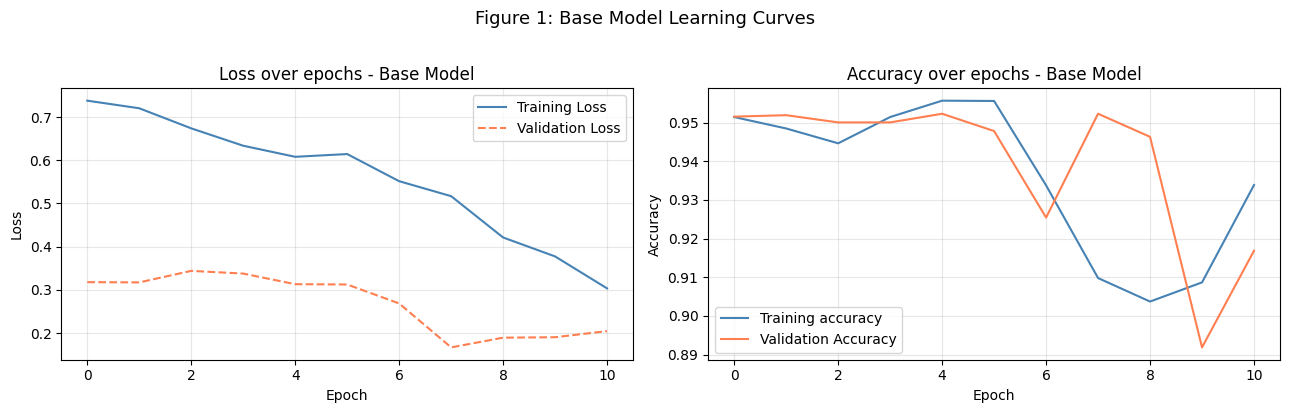

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (13, 4))

# Loss Curves
axes[0].plot(history.history['loss'], label = 'Training Loss', color = 'steelblue')
axes[0].plot(history.history['val_loss'], label = 'Validation Loss', color = 'coral', linestyle = '--')
axes[0].set_title('Loss over epochs - Base Model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

# Accuracy Curves
axes[1].plot(history.history['accuracy'], label = 'Training accuracy',   color = 'steelblue')
axes[1].plot(history.history['val_accuracy'], label = 'Validation Accuracy', color = 'coral')
axes[1].set_title('Accuracy over epochs - Base Model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

plt.suptitle('Figure 1: Base Model Learning Curves', fontsize = 13, y = 1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/baseline_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluating the Model

84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step


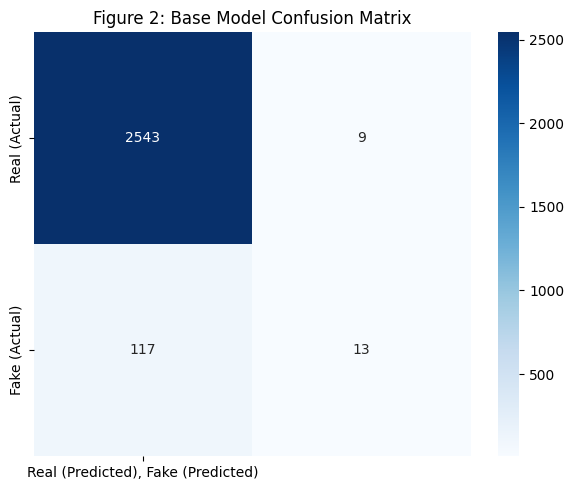

Classification Report - Base Model
              precision    recall  f1-score   support

        Real       0.96      1.00      0.98      2552
        Fake       0.59      0.10      0.17       130

    accuracy                           0.95      2682
   macro avg       0.77      0.55      0.57      2682
weighted avg       0.94      0.95      0.94      2682



In [ ]:
# Generate predictions from the test set
y_prediction_probability = model.predict(X_test)

# Convert the probability to labels for the classes

PREDICTION_THRESHOLD = 0.5
y_prediction = (y_prediction_probability > PREDICTION_THRESHOLD).astype(int).flatten()

# Use the predictions to create a confusion matrix
cm = confusion_matrix(y_test, y_prediction)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real (Predicted), Fake (Predicted)'], yticklabels=['Real (Actual)', 'Fake (Actual)'])
plt.title('Figure 2: Base Model Confusion Matrix')
plt.tight_layout()
plt.show()

# Print a Classification report
print('Classification Report - Base Model')
print(classification_report(y_test, y_prediction, target_names = ['Real', 'Fake']))

# Parameter Experimentation
* Experiment with different values for the models and compare the results to find the best model possible

# Helper Function
* This functions helps with training multiple models easily with different parameters and seeing their results.

In [ ]:
# Helper function to train the model + test its F1 Score

def run_model(name, batch_size = 64, learning_rate = 0.001, dropout_1 = 0.4, dropout_2 = 0.3):
  print('-------')
  print(f'Running {name}')
  print(f'Batch Size: {batch_size}, learning rate: {learning_rate}, Dropout: {dropout_1, dropout_2}')
  print('-------')

  curr_model = build_model(dropout_1 = dropout_1, dropout_2 = dropout_2, learning_rate = learning_rate)

  curr_early_stop = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True, verbose = 0)

  curr_history = curr_model.fit(X_train, y_train, epochs = EPOCHS, batch_size = batch_size, validation_data = (X_val, y_val), callbacks = [curr_early_stop], class_weight = class_weights_dict, verbose = 0)

  curr_y_prediction = (curr_model.predict(X_test) > PREDICTION_THRESHOLD).astype(int).flatten()
  curr_report = classification_report(y_test, curr_y_prediction, output_dict = True)
  f1_fake = round(curr_report['1']['f1-score'], 3)
  epochs_run = len(curr_history.history['loss'])

  print(f'Epochs Run: {epochs_run}')
  print(f'F1 Score: {f1_fake}')

  return curr_model, curr_history, f1_fake, epochs_run


# Different Model Experiments
* Base Model
* Larger Batch Size
* Lower Learning Rate
* Higher Dropout

In [ ]:
# Base Model
y_base_model = (model.predict(X_test) > PREDICTION_THRESHOLD).astype(int).flatten()
report_base_model = classification_report(y_test, y_base_model, output_dict = True)

model_results = [{
    'Experiment': 'Base Model',
    'Batch Size': 64,
    'Learning Rate': 0.001,
    'Dropout': '0.4 / 0.3',
    'F1 (Fake)': round(report_base_model['1']['f1-score'], 3),
    'Epochs Run': len(history.history['loss'])
}]

# Experiment 1
m1, h1, f1_1, ep1 = run_model(
    'Experiment 1: Larger Batch Size', batch_size = 128
)

model_results.append({
    'Experiment': 'Experiment 1: Batch Size 128',
    'Batch Size': 128,
    'Learning Rate': 0.001,
    'Dropout': '0.4 / 0.3',
    'F1 (Fake)': f1_1,
    'Epochs Run': ep1
})

# Experiment 2
m2, h2, f1_2, ep2 = run_model(
    'Experiment 2: Lower Learning Rate', learning_rate = 0.0005
)

model_results.append({
    'Experiment': 'Experiment 2: Learning rate: 0.0005',
    'Batch Size': 64,
    'Learning Rate': 0.0005,
    'Dropout': '0.4 / 0.3',
    'F1 (Fake)': f1_2,
    'Epochs Run': ep2
})

# Experiment 3
m3, h3, f1_3, ep3 = run_model(
    'Experiment 2: Higher Dropout', dropout_1 = 0.5, dropout_2 = 0.4
)

model_results.append({
    'Experiment': 'Experiment 3: Dropout: 0.5 / 0.4',
    'Batch Size': 64,
    'Learning Rate': 0.001,
    'Dropout': '0.5 / 0.4',
    'F1 (Fake)': f1_3,
    'Epochs Run': ep3
})


84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step
-------
Running Experiment 1: Larger Batch Size
Batch Size: 128, learning rate: 0.001, Dropout: (0.4, 0.3)
-------
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step
Epochs Run: 5
F1 Score: 0.063
-------
Running Experiment 2: Lower Learning Rate
Batch Size: 64, learning rate: 0.0005, Dropout: (0.4, 0.3)
-------
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 197ms/step
Epochs Run: 14
F1 Score: 0.422
-------
Running Experiment 2: Higher Dropout
Batch Size: 64, learning rate: 0.001, Dropout: (0.5, 0.4)
-------
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 206ms/step
Epochs Run: 20
F1 Score: 0.697


# Experiment Comparison Table

In [ ]:
results_df = pd.DataFrame(model_results)
print("Experiment Results")
print(results_df.to_string(index=False))

Experiment Results
                         Experiment  Batch Size  Learning Rate   Dropout  F1 (Fake)  Epochs Run
                         Base Model          64         0.0010 0.4 / 0.3      0.171          11
       Experiment 1: Batch Size 128         128         0.0010 0.4 / 0.3      0.063           5
Experiment 2: Learning rate: 0.0005          64         0.0005 0.4 / 0.3      0.422          14
   Experiment 2: Dropout: 0.5 / 0.4          64         0.0010 0.5 / 0.4      0.697          20


# Evaluation of Best Model

In [ ]:
# Have these be whatever the best model from the above comparison table is
best_model = m3
best_history = h3
best_name = 'Experiment 3: Dropout: 0.5 / 0.4'

# Final predictions
y_final_prob = best_model.predict(X_test)
y_final_prediction = (y_final_prob > PREDICTION_THRESHOLD).astype(int).flatten()


84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 229ms/step


# Plot learning curves for best model

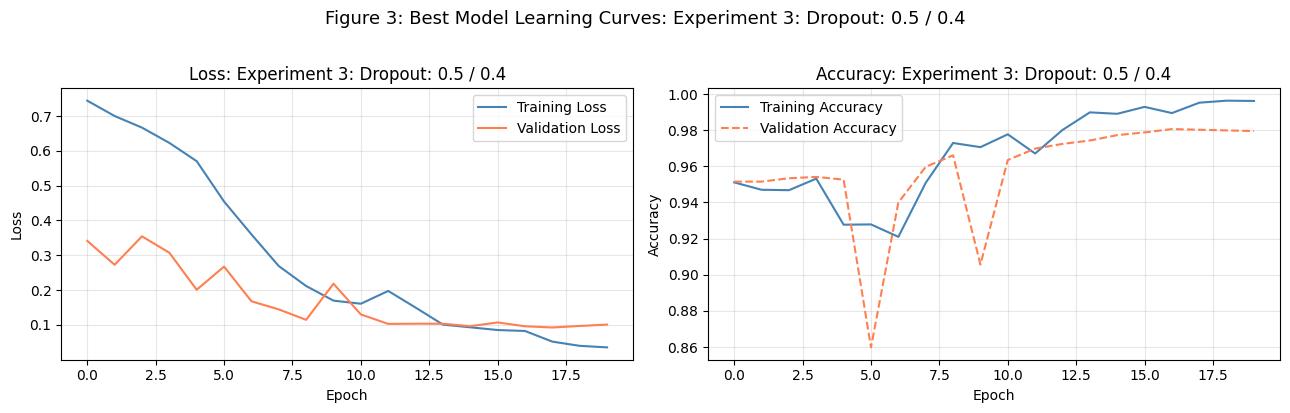

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (13, 4))

axes[0].plot(best_history.history['loss'], label='Training Loss', color='steelblue')
axes[0].plot(best_history.history['val_loss'], label = 'Validation Loss', color = 'coral')
axes[0].set_title(f'Loss: {best_name}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_history.history['accuracy'], label = 'Training Accuracy', color = 'steelblue')
axes[1].plot(best_history.history['val_accuracy'], label = 'Validation Accuracy', color = 'coral', linestyle='--')
axes[1].set_title(f'Accuracy: {best_name}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

plt.suptitle(f'Figure 3: Best Model Learning Curves: {best_name}', fontsize = 13, y = 1.02)
plt.tight_layout()
plt.show()

# Create Confusion Matrix of best model

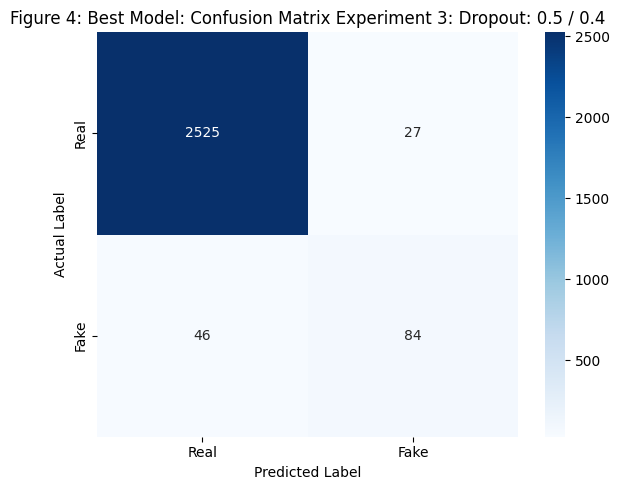

Final Classification Report — Experiment 3: Dropout: 0.5 / 0.4:
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      2552
        Fake       0.76      0.65      0.70       130

    accuracy                           0.97      2682
   macro avg       0.87      0.82      0.84      2682
weighted avg       0.97      0.97      0.97      2682



In [ ]:
# Confusion Matrix based on the results of the best model
cm_best = confusion_matrix(y_test, y_final_prediction)

plt.figure(figsize = (6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title(f'Figure 4: Best Model: Confusion Matrix {best_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"Final Classification Report — {best_name}:")
print(classification_report(y_test, y_final_prediction, target_names=['Real', 'Fake']))

# Example Predictions
* This randomly seleects predictions made by the best model and displays the results

In [ ]:
# Selects random positions within the test split and shows the predictions the model gave

example_indexs = np.random.choice(len(X_test), size = 8, replace = False)

print("Example predictions on test split")
print(f"{'Index':<8} {'Actual':<10} {'Predicted':<12} {'Confidence':<12} {'Correct?'}")
print("--------------------------------------------------------")

for i in example_indexs:
    actual    = "FAKE" if y_test[i] == 1 else "real"
    predicted = "FAKE" if y_final_prediction[i] == 1 else "real"
    confidence = float(y_final_prob[i])
    correct   = "Correct" if y_test[i] == y_final_prediction[i] else "Incorrect"
    print(f"{i:<8} {actual:<10} {predicted:<12} {confidence:<12.3f} {correct}")

Example predictions on test split
Index    Actual     Predicted    Confidence   Correct?
--------------------------------------------------------
322      real       real         0.005        Correct
2040     real       real         0.038        Correct
2343     real       real         0.038        Correct
1026     real       real         0.035        Correct
537      real       real         0.114        Correct
2412     real       real         0.005        Correct
886      real       real         0.113        Correct
1008     real       real         0.080        Correct


/tmp/ipykernel_6519/36231264.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  confidence = float(y_final_prob[i])
